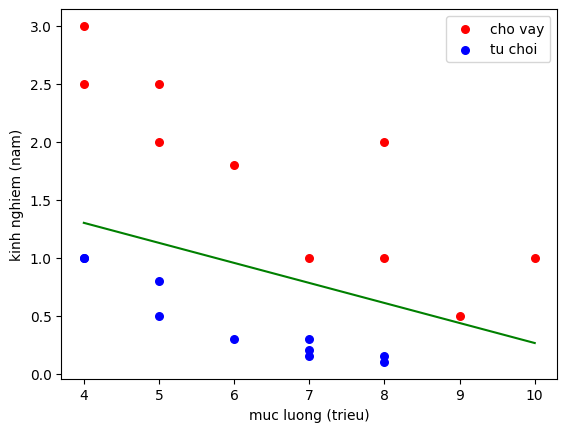

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Hàm sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Load dữ liệu
data = pd.read_csv('dataset.csv').values
N, d = data.shape

# Feature và label
x = data[:,0:d-1].reshape(-1, d-1)
y = data[:,2].reshape(-1,1)

# Vẽ dữ liệu
plt.scatter(x[:10,0], x[:10,1], c='red', s=30, label='cho vay')
plt.scatter(x[10:,0], x[10:,1], c='blue', s=30, label='tu choi')

plt.xlabel("muc luong (trieu)")
plt.ylabel("kinh nghiem (nam)")
plt.legend()

# Thêm cột bias
X = np.hstack((np.ones((N,1)), x))

# Khởi tạo trọng số
w = np.array([0.,0.1,0.1]).reshape(-1,1)

# Gradient Descent
numOfIteration = 1000
cost = np.zeros(numOfIteration)

learning_rate = 0.01
epsilon = 1e-10

for i in range(numOfIteration):

    # Dự đoán
    y_predict = sigmoid(np.dot(X,w))

    # Tính loss
    cost[i] = -np.sum(y*np.log(y_predict+epsilon) + (1-y)*np.log(1-y_predict+epsilon))

    # Gradient descent
    w = w - learning_rate * np.dot(X.T, (y_predict - y))

    #print(cost[i])

# Vẽ decision boundary
x1 = np.linspace(4,10,100)
x2 = -(w[0] + w[1]*x1) / w[2]

plt.plot(x1, x2, 'g')

plt.show()